# Marketing Traffic Regression — Demo Project

## 1. Business question
How can we predict website traffic (number of visits) based on simple factors  
like time of day **and** day of week?

## 2. Steps
1. Create a synthetic (but realistic) dataset for marketing traffic  
2. Explore the data (plots + summary statistics)  
3. Build a simple regression model (e.g. Linear Regression)  
4. Evaluate performance (R², error)  
5. Translate results into a plain-English business insight  

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Create synthetic dataset
np.random.seed(42)

hours = np.random.randint(0, 24, size=200)        # hour of day
day_of_week = np.random.randint(0, 7, size=200)   # day 0–6
traffic = (hours * 5) + (day_of_week * 20) + np.random.randint(-30, 30, size=200)

df = pd.DataFrame({
    'Hour': hours,
    'DayOfWeek': day_of_week,
    'Traffic': traffic
})

df.head()

,Hour,DayOfWeek,Traffic
0,6,0,39
1,19,4,177
2,14,0,48
3,10,0,62
4,7,2,98


In [3]:
# 2. Explore the dataset

df.describe()

,Hour,DayOfWeek,Traffic
count,200.000000,200.000000,200.000000
mean,11.000000,2.775000,111.725000
std,6.969424,2.006115,59.265431
min,0.000000,0.000000,-19.000000
25%,6.000000,1.000000,69.750000
50%,11.000000,3.000000,105.500000
75%,17.000000,5.000000,153.250000
max,23.000000,6.000000,256.000000


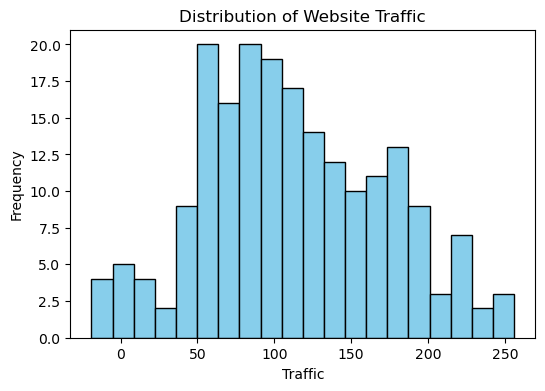

In [4]:
# Traffic distribution
plt.figure(figsize=(6,4))
plt.hist(df['Traffic'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Website Traffic")
plt.xlabel("Traffic")
plt.ylabel("Frequency")
plt.show()

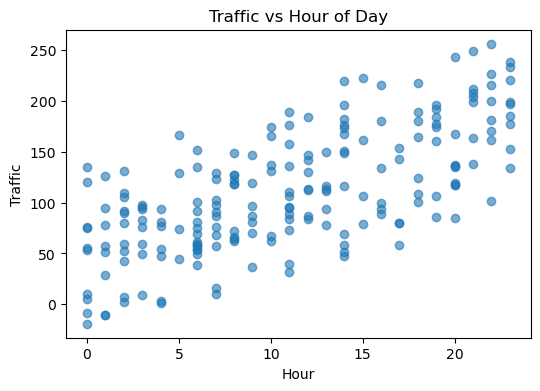

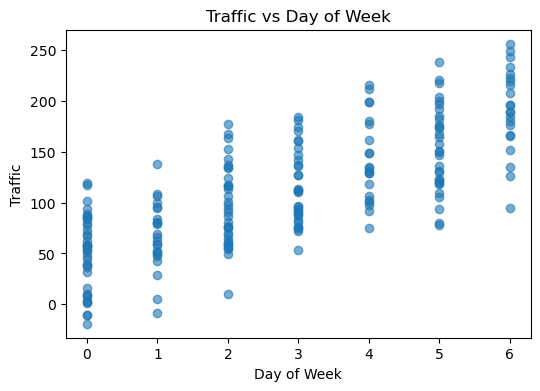

In [5]:
# Relationship between features and traffic
plt.figure(figsize=(6,4))
plt.scatter(df['Hour'], df['Traffic'], alpha=0.6)
plt.title("Traffic vs Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Traffic")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['DayOfWeek'], df['Traffic'], alpha=0.6)
plt.title("Traffic vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Traffic")
plt.show()

In [6]:
# 3. Build a simple regression model (Linear Regression)

# Features (X) and target (y)
X = df[['Hour', 'DayOfWeek']]
y = df['Traffic']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [7]:
# 4. Evaluate performance

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, mae, rmse

(0.8970478182744299, 15.870051286588046, np.float64(18.294311754808245))

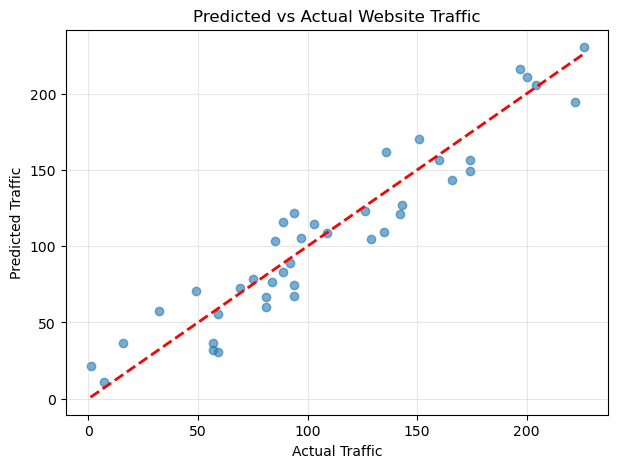

In [8]:
# 5. Visualize predictions vs actual values

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2)

plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")
plt.title("Predicted vs Actual Website Traffic")

plt.grid(alpha=0.3)
plt.show()

## 6. Business Interpretation

The aim of this project was to understand how website traffic varies across time and to build a simple model that predicts traffic based on hour of day and day of week. These insights can help marketing teams optimise campaign timing, plan resources, and better understand user behaviour patterns.

### Model performance  
The regression model performed strongly:

- **R² ≈ 0.897** → the model explains about **90% of the variation** in website traffic  
- **MAE ≈ 15.9** → on average, predictions are within ~16 visitors of the true value  
- **RMSE ≈ 18.3** → typical prediction error is roughly 18 visitors  

This indicates that even with just two basic variables (Hour and DayOfWeek), the model captures most of the behaviour of traffic patterns.

### Key insights  
- **Hour of the day** is the dominant driver of traffic. Peak hours show substantially higher activity, while very early hours have consistently lower traffic.  
- **Day of the week** also matters, with weekdays generally having higher baseline traffic than weekends.  

These patterns are intuitive and consistent with real-world digital behaviour, strengthening the reliability of the model.

### Business value  
This type of model can immediately support decision-making for marketing and operations:

- **Scheduling marketing campaigns** during high-traffic windows  
- **Optimising posting times** for social or paid content  
- **Forecasting daily traffic** for resource and support planning  
- **Detecting anomalies** (e.g., sudden drops/spikes vs expected patterns)  
- **Providing a baseline** for more advanced forecasting models  

Overall, the model provides a clear, data-driven view of when users are most active, and offers an accurate starting point for traffic prediction and campaign optimisation.